<a href="https://colab.research.google.com/github/SastaGhost/data-analytics-project/blob/main/dewali_sales_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Diwali Sales Data.csv to Diwali Sales Data (1).csv


In [ ]:
df = pd.read_csv("Diwali Sales Data.csv",encoding="latin1")
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,Teenager,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,Adult,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,Adult,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,Teenager,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,Teenager,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11239 entries, 0 to 11238
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [ ]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True, errors='ignore')
df.dropna(inplace=True)
df.rename(columns={
    'Cust_name': 'Customer_Name',
    'Prod_cat': 'Product_Category'
}, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.to_csv("diwali_cleaned.csv", index=False)





In [ ]:
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Amount'] >= Q1 - 1.5*IQR) &
        (df['Amount'] <= Q3 + 1.5*IQR)]


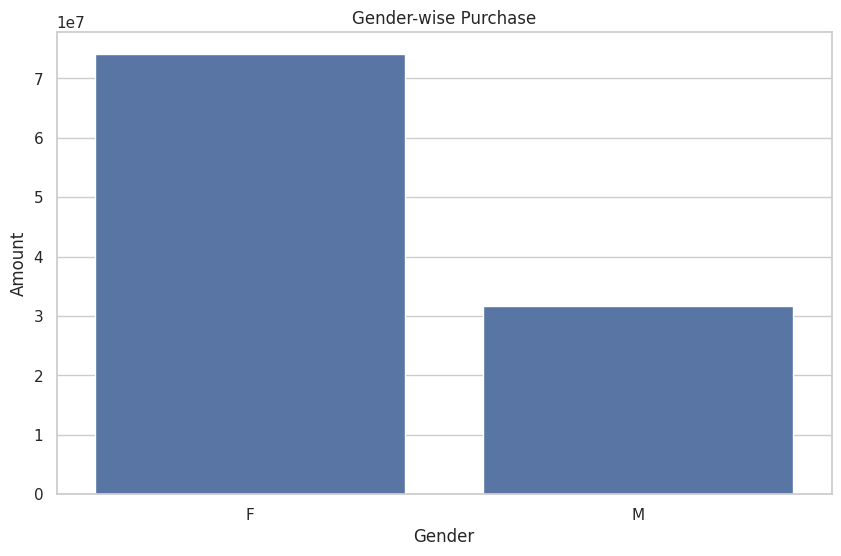

In [ ]:
gender_sales = df.groupby('Gender')['Amount'].sum().reset_index()

sns.barplot(x='Gender', y='Amount', data=gender_sales)
plt.title("Gender-wise Purchase")
plt.show()


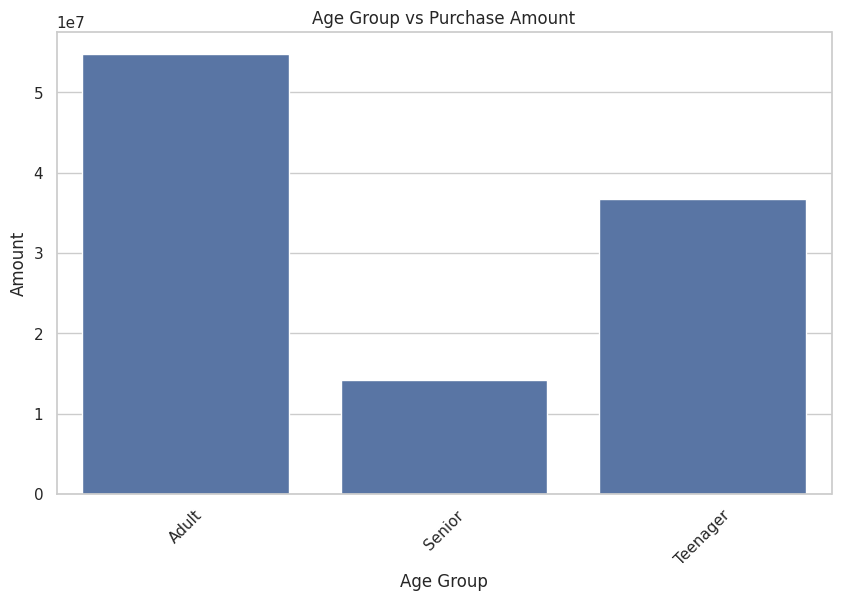

In [ ]:
age_sales = df.groupby('Age Group')['Amount'].sum().reset_index()

sns.barplot(x='Age Group', y='Amount', data=age_sales)
plt.title("Age Group vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()


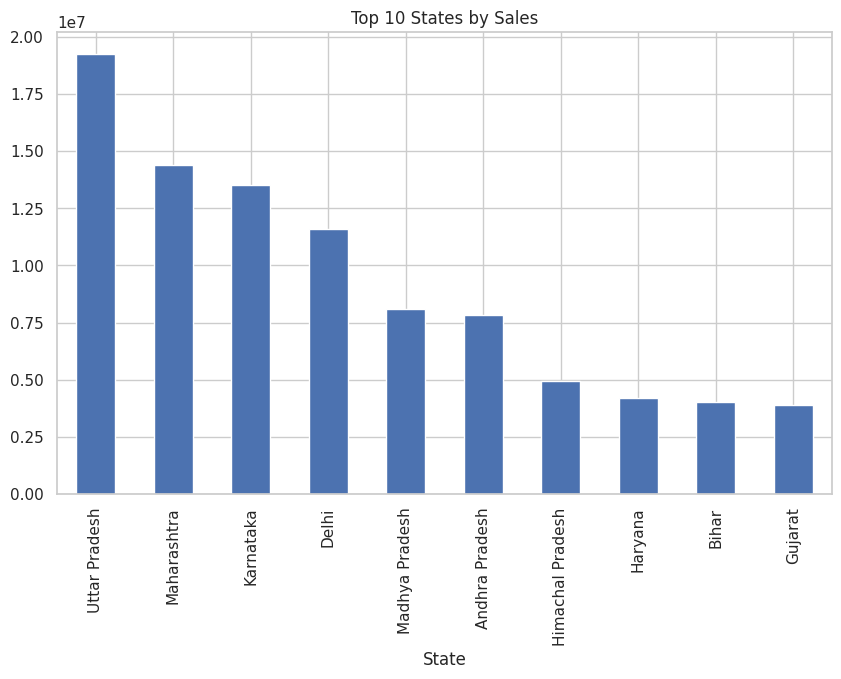

In [ ]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.show()


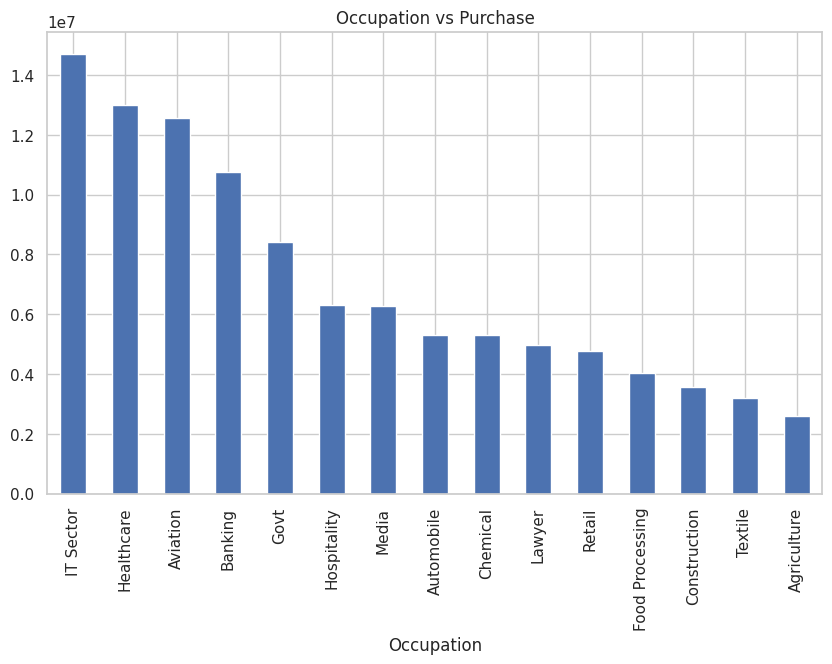

In [ ]:
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)

occupation_sales.plot(kind='bar')
plt.title("Occupation vs Purchase")
plt.show()


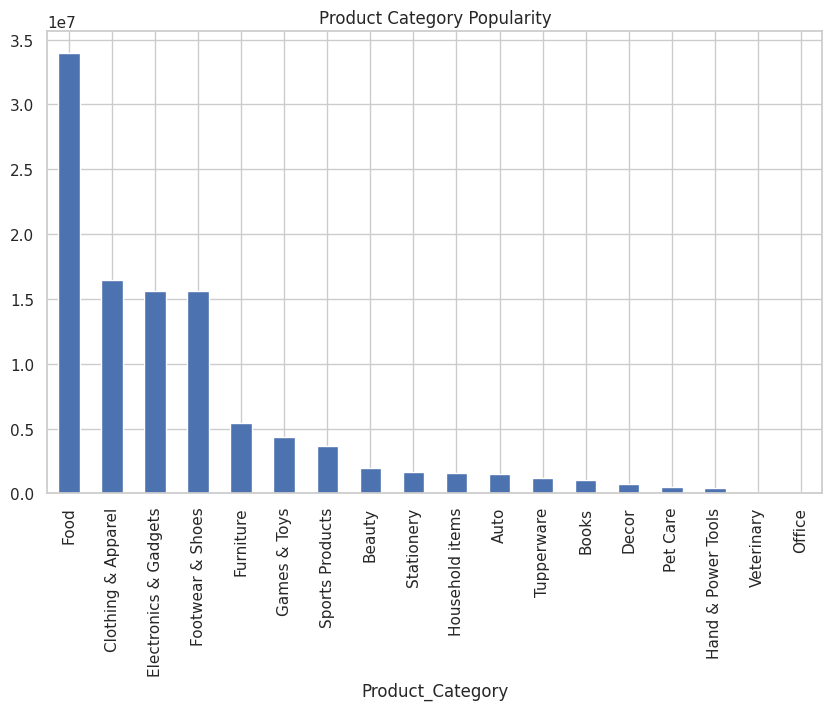

In [ ]:
product_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Product Category Popularity")
plt.show()


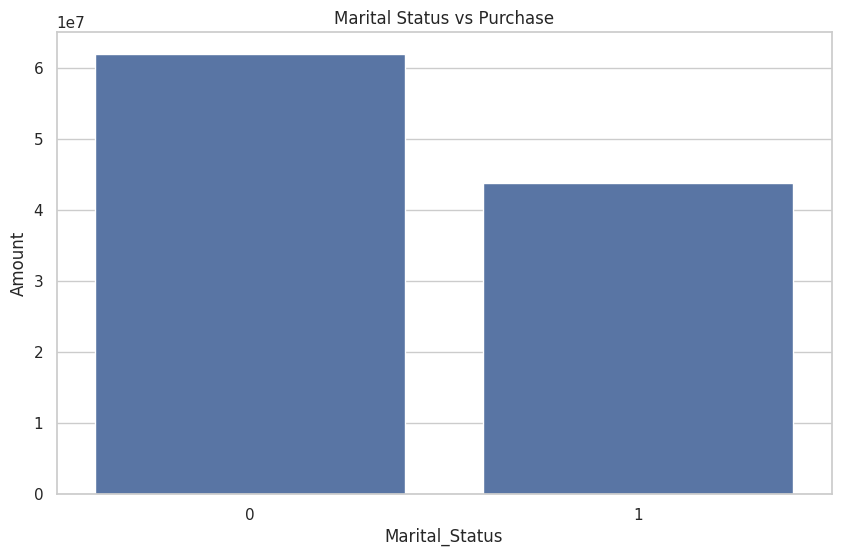

In [ ]:
marital_sales = df.groupby('Marital_Status')['Amount'].sum().reset_index()

sns.barplot(x='Marital_Status', y='Amount', data=marital_sales)
plt.title("Marital Status vs Purchase")
plt.show()


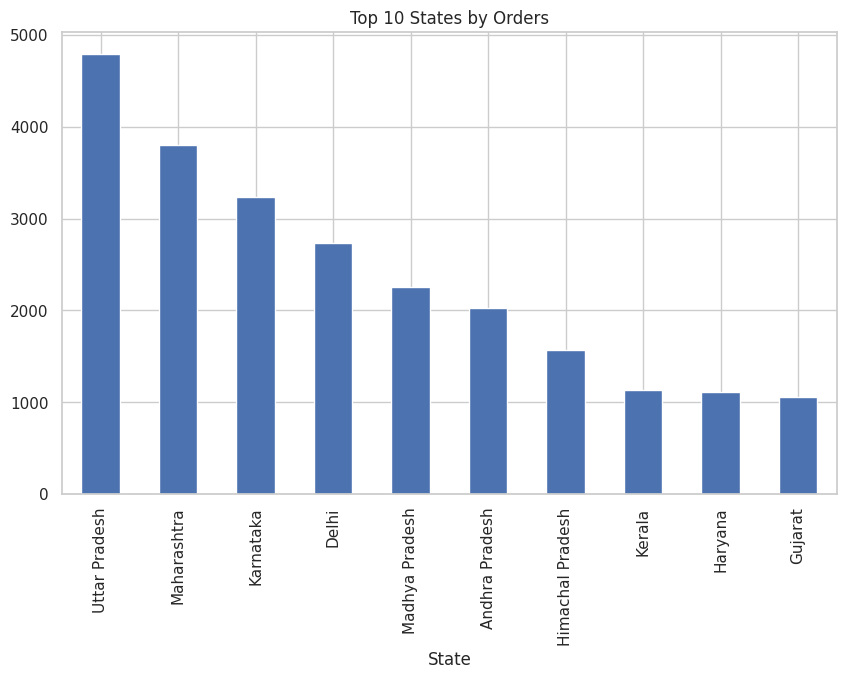

In [ ]:
top_orders = df.groupby('State')['Orders'].sum().sort_values(ascending=False).head(10)

top_orders.plot(kind='bar')
plt.title("Top 10 States by Orders")
plt.show()


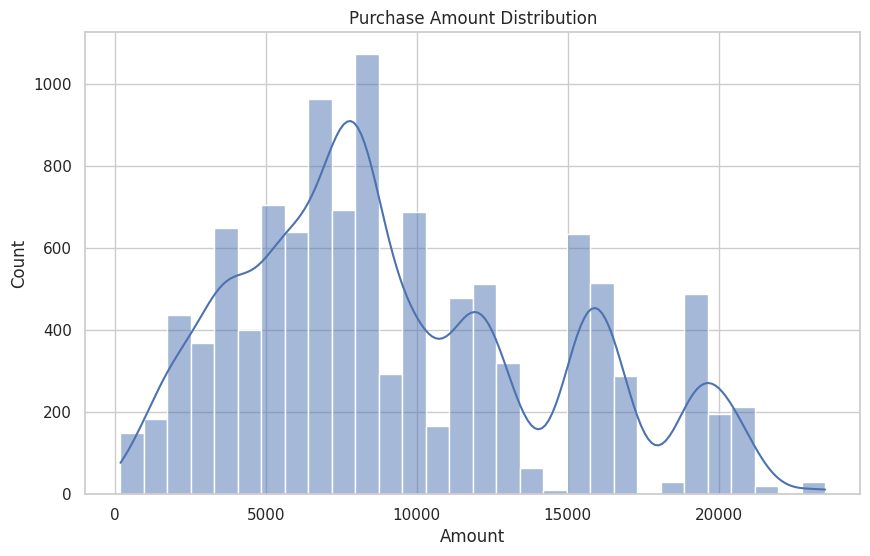

In [ ]:
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Purchase Amount Distribution")
plt.show()


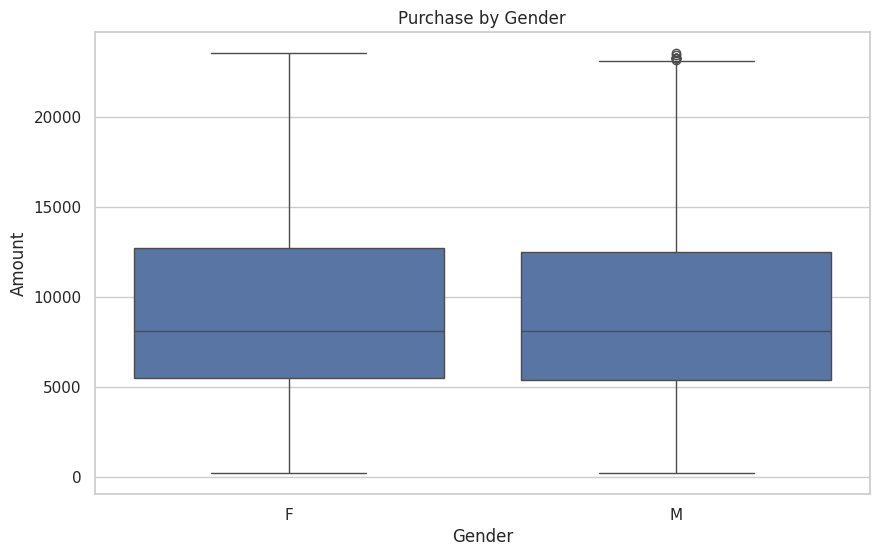

In [ ]:
sns.boxplot(x='Gender', y='Amount', data=df)
plt.title("Purchase by Gender")
plt.show()


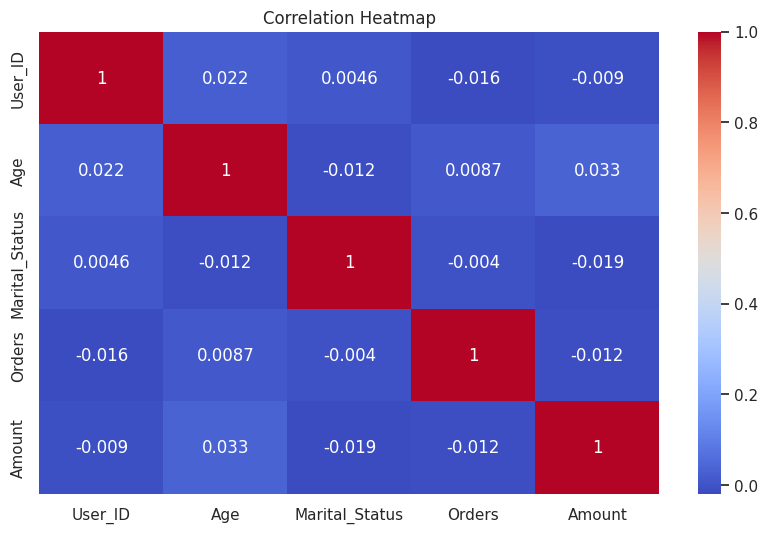

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
#cleaned file
from google.colab import files
files.download("diwali_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>